In [ ]:
import pickle
import scipy.sparse as sp
import pandas as pd

# ============================
# Load trained model
# ============================
with open("best_xgboost_model.pkl", "rb") as f:
    model = pickle.load(f)

# ============================
# Load sparse matrices
# ============================
X_train = sp.load_npz("X_train_processed.npz")
X_val   = sp.load_npz("X_val_processed.npz")
X_test  = sp.load_npz("X_test_processed.npz")

# ============================
# Load targets
# ============================
y_train = pd.read_csv("y_train.csv").squeeze()
y_val   = pd.read_csv("y_val.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

# ============================
# Load feature names
# ============================
with open("feature_names.pkl", "rb") as f:
    feature_names = pickle.load(f)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall   : {recall_score(y_test,y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test,y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test,y_prob):.4f}")

Accuracy : 0.9748
Precision: 0.9658
Recall   : 0.9206
F1 Score : 0.9426
ROC AUC  : 0.9632


In [ ]:
import shap
import pandas as pd

In [ ]:
clean_feature_names = [
    f.replace("remainder__", "").replace("onehot__", "")
    for f in feature_names
]

X_test_df = pd.DataFrame(
    X_test.toarray(),
    columns=clean_feature_names
)

In [ ]:
explainer = shap.TreeExplainer(model)

In [ ]:
shap_values = explainer.shap_values(X_test_df)

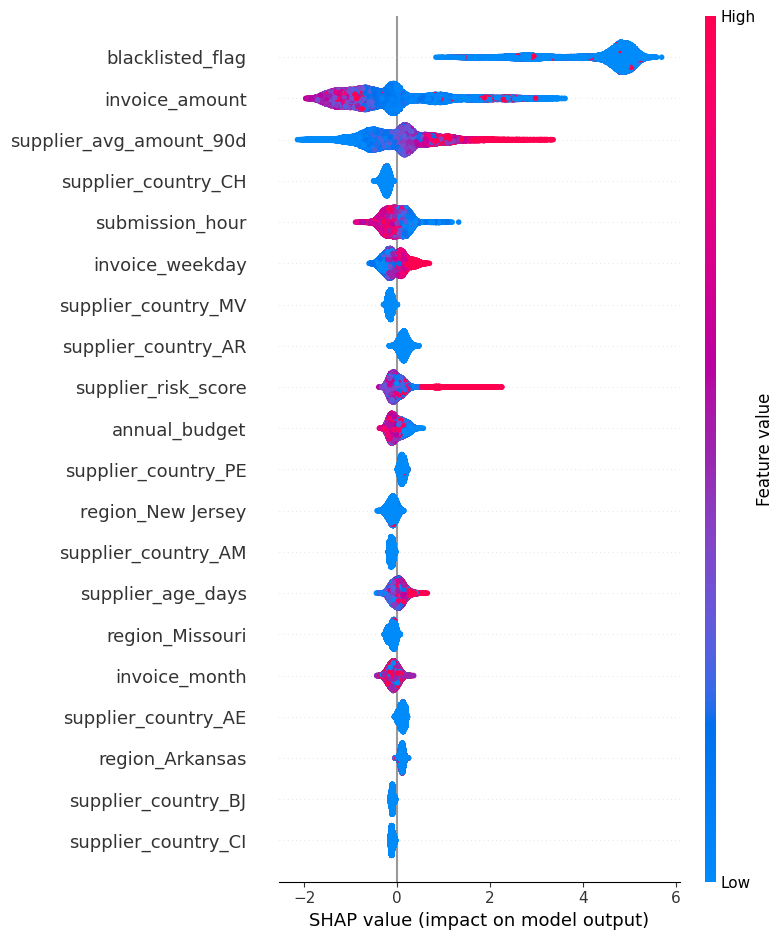

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_df
)

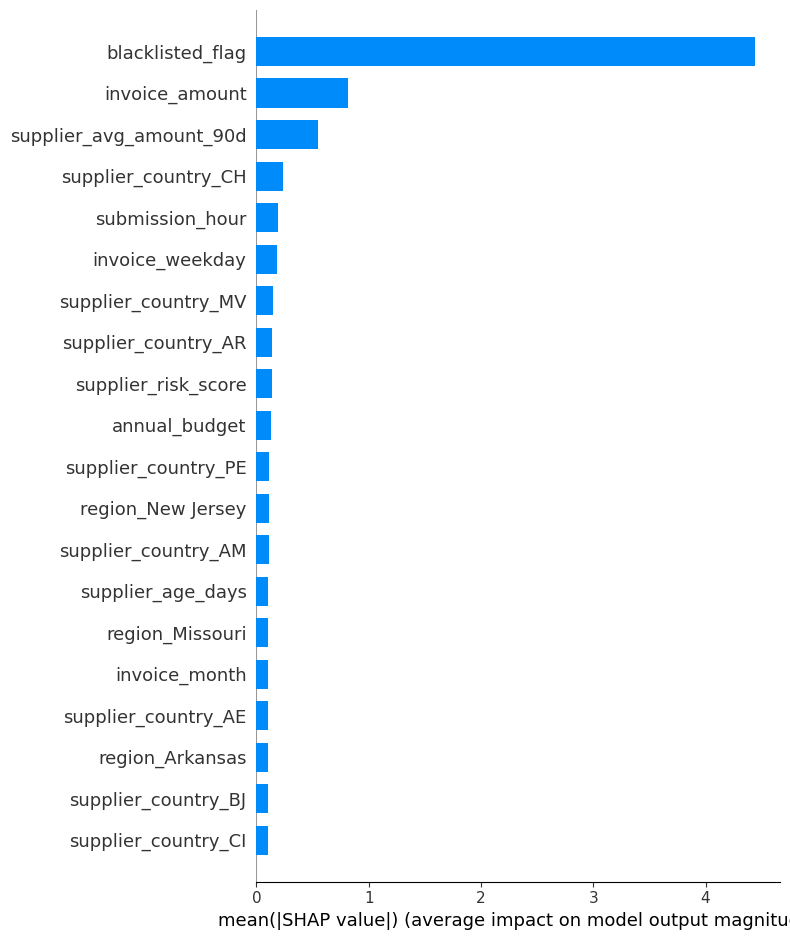

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type="bar"
)

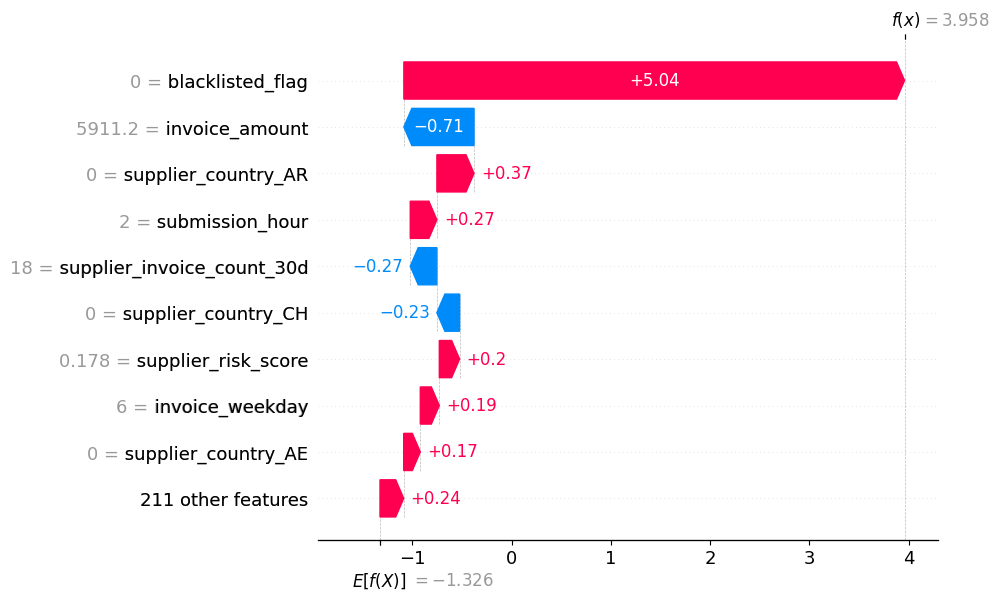

In [ ]:
invoice_id = 25

exp = shap.Explanation(
    values=shap_values[invoice_id],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[invoice_id].values,
    feature_names=X_test_df.columns.tolist()
)

shap.plots.waterfall(exp)

In [ ]:
shap.initjs()

shap.plots.force(exp)

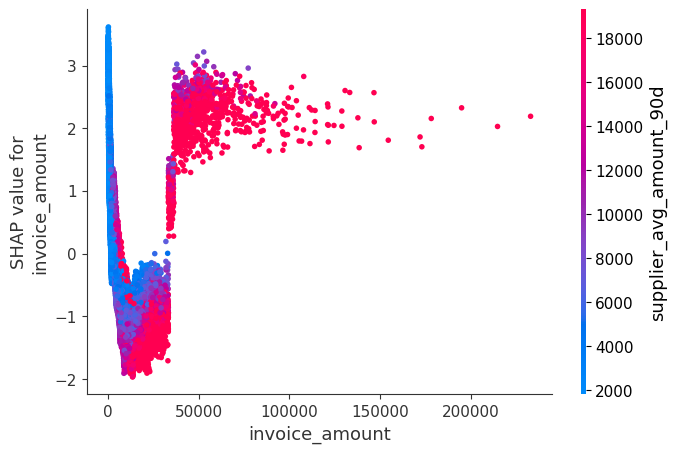

In [ ]:
shap.dependence_plot(
    "invoice_amount",
    shap_values,
    X_test_df
)